In [8]:
import os
import glob
import json
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torch
import random
from tensorboard.backend.event_processing import event_accumulator
from stable_baselines3.common.utils import set_random_seed # <-- KRİTİK EKSİK EKLENDİ

# Stable Baselines3
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

# Grafik Ayarları
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('seaborn-v0_8-whitegrid')

# Cihaz Seçimi
def get_optimal_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    elif torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_optimal_device()
print(f"🚀 Analiz Cihazı: {DEVICE}")



🚀 Analiz Cihazı: mps


In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack

# ==========================================
# 1. WRAPPERLAR (Sınır Uyumlu Düzeltme)
# ==========================================

class Float32ObservationWrapper(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        self.observation_space = gym.spaces.Box(
            low=env.observation_space.low,
            high=env.observation_space.high,
            shape=env.observation_space.shape,
            dtype=np.float32
        )
    def observation(self, observation):
        return np.array(observation, dtype=np.float32)

class RandomDampingWrapper(gym.Wrapper):
    def __init__(self, env, min_damping, max_damping):
        super().__init__(env)
        self.min_d = min_damping
        self.max_d = max_damping
        # store current damping so we can change it later
        self._current_damping = None

    def reset(self, seed=None, options=None):
        # choose new damping on reset
        try:
            rnd = self.np_random if hasattr(self, 'np_random') else np.random
            new_damping = rnd.uniform(self.min_d, self.max_d)
        except Exception:
            new_damping = np.random.uniform(self.min_d, self.max_d)
        self._current_damping = new_damping
        if hasattr(self.env.unwrapped, 'model'):
            dof_count = len(self.env.unwrapped.model.dof_damping)
            self.env.unwrapped.model.dof_damping[:] = np.full(dof_count, new_damping)
        return self.env.reset(seed=seed, options=options)

    def set_damping(self, value: float):
        """Set damping value on-the-fly (used by sudden-fault test)."""
        self._current_damping = float(value)
        if hasattr(self.env.unwrapped, 'model'):
            dof_count = len(self.env.unwrapped.model.dof_damping)
            self.env.unwrapped.model.dof_damping[:] = np.full(dof_count, self._current_damping)

class PreviousActionWrapper(gym.Wrapper):
    """
    [CRITICAL FIX] Observation Space sınırlarını (Bounds) korur.
    Model: [Obs (Unbounded) + Action (-1 to 1)]
    """
    def __init__(self, env):
        super().__init__(env)
        obs_space = env.observation_space
        act_space = env.action_space
        
        # 1. Sınırları Birleştir (Modelin beklediği hassas yapı)
        # Obs genelde -inf/inf olsa da, Action -1/1 arasındadır.
        low = np.concatenate([obs_space.low, act_space.low])
        high = np.concatenate([obs_space.high, act_space.high])
        
        # 2. Space Tanımı
        self.observation_space = gym.spaces.Box(
            low=low, 
            high=high, 
            dtype=np.float32
        )
        self.prev_action = np.zeros(act_space.shape[0], dtype=np.float32)

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.prev_action = np.zeros_like(self.prev_action)
        return self._get_obs(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        aug_obs = self._get_obs(obs)
        self.prev_action = action.astype(np.float32)
        return aug_obs, reward, terminated, truncated, info

    def _get_obs(self, current_obs):
        return np.concatenate([current_obs, self.prev_action]).astype(np.float32)

# ==========================================
# 2. OOD EVALUATION (Matplotlib Fix)
# ==========================================

def evaluate_ood_compare(models_map, n_episodes=30):
    print(f"\n🧪 OOD TESTİ BAŞLIYOR (Damping: 3.0 - 5.0)")
    
    def make_ood_env():
        env = gym.make("Reacher-v5")
        env = Float32ObservationWrapper(env)
        env = RandomDampingWrapper(env, min_damping=3.0, max_damping=5.0)
        env = PreviousActionWrapper(env) # Artık sınırları doğru
        return env

    env_base = DummyVecEnv([make_ood_env])
    results = {}

    for name, path in models_map.items():
        print(f"   ► Testing: {name}...")
        
        # FrameStack
        if name == "FrameStack": 
            eval_env = VecFrameStack(env_base, n_stack=4)
        else: 
            eval_env = env_base
            if hasattr(eval_env, 'stack_frames'): eval_env = env_base 

        # Yükle
        try:
            if name == "LSTM": 
                model = RecurrentPPO.load(path, env=eval_env, device="cpu")
            else: 
                model = PPO.load(path, env=eval_env, device="cpu")
        except Exception as e:
            print(f"     ❌ HATA: {e}")
            continue
            
        scores = []
        for _ in range(n_episodes):
            obs = eval_env.reset()
            done = False
            total = 0
            lstm_states = None
            starts = np.ones((1,), dtype=bool)
            
            while not done:
                if name == "LSTM":
                    action, lstm_states = model.predict(obs, state=lstm_states, episode_start=starts, deterministic=True)
                else:
                    action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _ = eval_env.step(action)
                total += reward[0]
                starts = done
            scores.append(total)
        results[name] = scores

    # Raporlama
    if results:
        print("\n📊 OOD SONUÇLARI")
        print("-" * 10)
        print(f"{'Model':<15} | {'Mean':<10} | {'Std':<10}")
        print("-" * 10)
        for k, v in results.items():
            print(f"{k:<15} | {np.mean(v):<10.2f} | {np.std(v):<10.2f}")

        plt.figure(figsize=(10, 6))
        # MatplotlibDeprecationWarning FIX: labels -> tick_labels
        plt.boxplot(results.values(), tick_labels=results.keys(), patch_artist=True)
        plt.title("OOD Generalization Gap Test")
        plt.ylabel("Total Reward")
        plt.grid(True, alpha=0.3)
        plt.show()

# Testi Çalıştır
if 'paths_vanilla' in locals():
    models_map = {
        "Vanilla": paths_vanilla[0],
        "FrameStack": paths_framestack[0],
        "LSTM": paths_lstm[0]
    }
    evaluate_ood_compare(models_map)
else:
    print("⚠️ Model yolları (paths_vanilla vb.) bulunamadı.")

⚠️ Model yolları (paths_vanilla vb.) bulunamadı.


In [3]:
def get_latest_run_dir(base_path="../data/logs"):
    if not os.path.exists(base_path):
        raise FileNotFoundError(f"Log klasörü yok: {base_path}")
    
    all_subdirs = [os.path.join(base_path, d) for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    if not all_subdirs:
        raise FileNotFoundError("Hiçbir deney bulunamadı!")
    return max(all_subdirs, key=os.path.getmtime)

def find_model_paths(run_dir):
    """Klasördeki modelleri otomatik tanır (Genellikle seed_42)."""
    models = {}
    target_seed = "seed_42" # Analiz için baz alınan seed
    
    for file in os.listdir(run_dir):
        if file.endswith(".zip") and target_seed in file:
            path = os.path.join(run_dir, file)
            if "Vanilla" in file: models["Vanilla"] = path
            elif "FrameStack" in file: models["FrameStack"] = path
            elif "LSTM" in file: models["LSTM"] = path
    return models

# Otomatik Çalıştır
latest_run = get_latest_run_dir()
models_map = find_model_paths(latest_run)

print(f"📂 Analiz Klasörü: {os.path.basename(latest_run)}")
print(f"🧠 Yüklenen Modeller: {list(models_map.keys())}")

📂 Analiz Klasörü: Phase-3.1-Comparison_20251125_124418
🧠 Yüklenen Modeller: ['Vanilla', 'FrameStack', 'LSTM']


📊 TensorBoard Verileri Okunuyor...


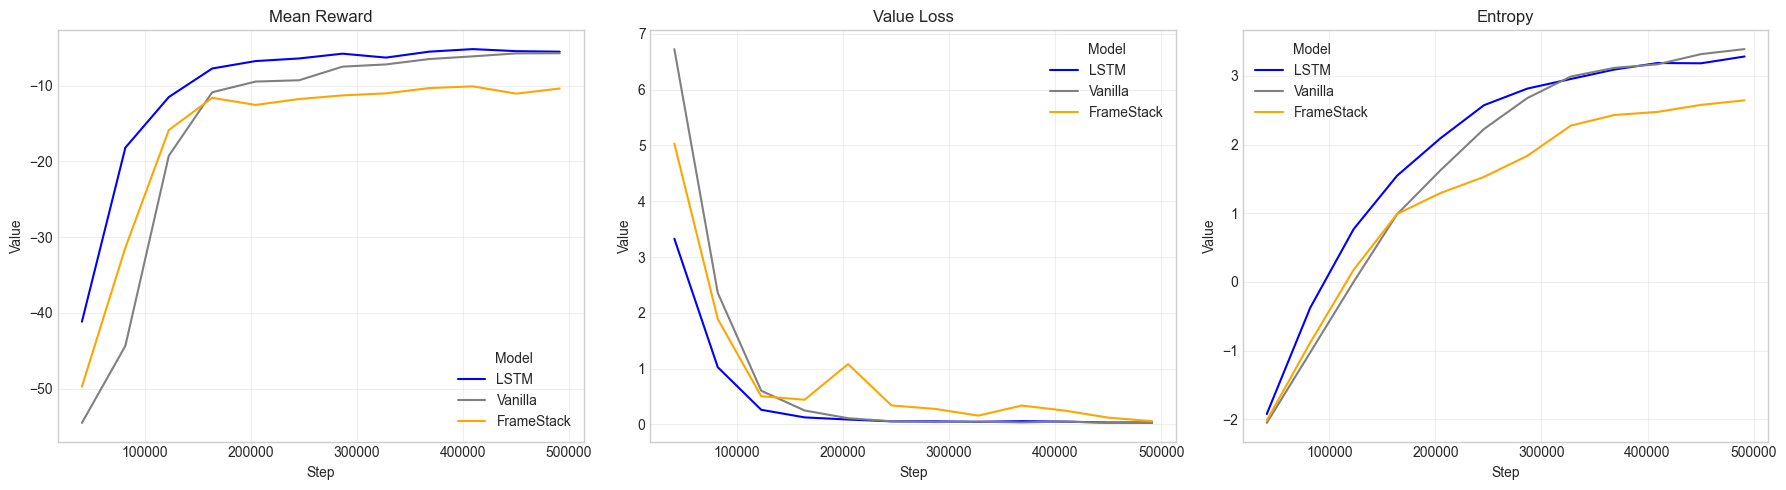

In [4]:
def plot_training_curves(log_dir):
    print(f"📊 TensorBoard Verileri Okunuyor...")
    metrics = {"rollout/ep_rew_mean": "Mean Reward", "train/value_loss": "Value Loss", "train/entropy_loss": "Entropy"}
    data = []
    
    for root, _, files in os.walk(log_dir):
        for file in files:
            if "events.out.tfevents" in file:
                run_name = os.path.basename(root)
                if "Vanilla" in run_name: model = "Vanilla"
                elif "FrameStack" in run_name: model = "FrameStack"
                elif "LSTM" in run_name: model = "LSTM"
                else: continue

                try:
                    ea = event_accumulator.EventAccumulator(os.path.join(root, file), size_guidance={event_accumulator.SCALARS: 0})
                    ea.Reload()
                    for tag, nice_name in metrics.items():
                        if tag in ea.Tags()['scalars']:
                            for e in ea.Scalars(tag):
                                data.append({"Step": e.step, "Value": e.value, "Metric": nice_name, "Model": model})
                except: pass
    
    if not data: return print("⚠️ Veri yok.")

    df = pd.DataFrame(data)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    palette = {"Vanilla": "gray", "FrameStack": "orange", "LSTM": "blue"}
    
    for i, m in enumerate(metrics.values()):
        sns.lineplot(data=df[df["Metric"]==m], x="Step", y="Value", hue="Model", ax=axes[i], palette=palette)
        axes[i].set_title(m)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_curves(latest_run)


🧪 OOD TESTİ BAŞLIYOR (Damping: 3.0 - 5.0)
   ► Testing: Vanilla...


/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/berkaygurkan/pytorch_m1_env/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


   ► Testing: FrameStack...
   ► Testing: LSTM...
   ► Testing: LSTM...

📊 OOD SONUÇLARI
--------------------------------------------------
Model           | Mean       | Std       
--------------------------------------------------
Vanilla         | -6.51      | 3.28      
FrameStack      | -7.96      | 3.33      
LSTM            | -5.77      | 2.87      

📊 OOD SONUÇLARI
--------------------------------------------------
Model           | Mean       | Std       
--------------------------------------------------
Vanilla         | -6.51      | 3.28      
FrameStack      | -7.96      | 3.33      
LSTM            | -5.77      | 2.87      


/var/folders/4n/h53cm6q91g98gmfnx47w5_200000gn/T/ipykernel_3567/1239316227.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results.values(), labels=results.keys(), patch_artist=True)


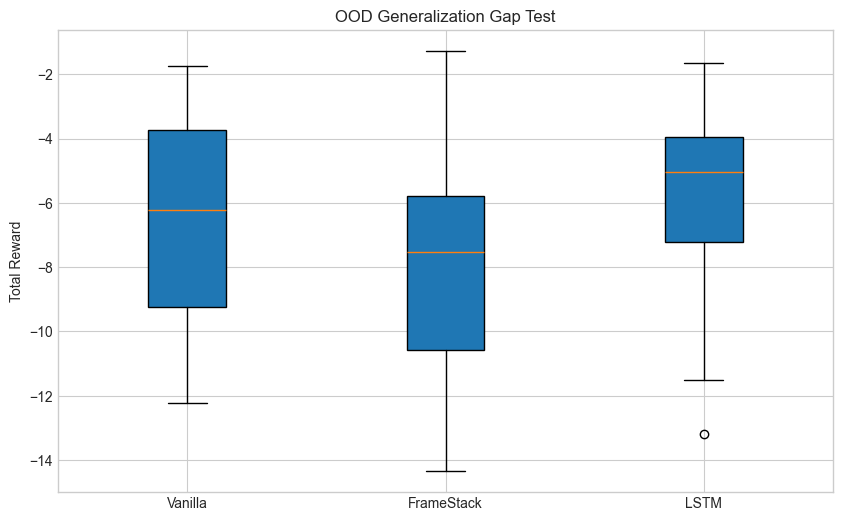

In [6]:
def evaluate_ood(models, n_episodes=30):
    print(f"\n🧪 OOD TESTİ BAŞLIYOR (Damping: 3.0 - 5.0)")
    
    # --- ORTAM KURULUMU (Eğitimle Aynı Yapı) ---
    def make_ood_env():
        env = gym.make("Reacher-v5")
        env = Float32ObservationWrapper(env)
        # ZOR MOD: Damping [3.0, 5.0]
        env = RandomDampingWrapper(env, min_damping=0.1, max_damping=10.0)
        # Model 12 boyutlu olduğu için PreviousActionWrapper kullanıyoruz
        env = PreviousActionWrapper(env)
        return env

    env_base = DummyVecEnv([make_ood_env])
    results = {}

    for name, path in models.items():
        print(f"   ► Testing: {name}...")
        
        # FrameStack
        if name == "FrameStack": eval_env = VecFrameStack(env_base, n_stack=4)
        else: eval_env = env_base
        if name != "FrameStack" and hasattr(eval_env, 'stack_frames'): eval_env = env_base 

        # Yükle
        try:
            if name == "LSTM": model = RecurrentPPO.load(path, env=eval_env, device="cpu")
            else: model = PPO.load(path, env=eval_env, device="cpu")
        except ValueError as e:
            print(f"     ❌ BOYUT HATASI: {e}")
            continue
            
        scores = []
        for _ in range(n_episodes):
            obs = eval_env.reset()
            done = False
            total = 0
            lstm_states = None
            starts = np.ones((1,), dtype=bool)
            while not done:
                if name == "LSTM":
                    action, lstm_states = model.predict(obs, state=lstm_states, episode_start=starts, deterministic=True)
                else:
                    action, _ = model.predict(obs, deterministic=True)
                obs, reward, done, _ = eval_env.step(action)
                total += reward[0]
                starts = done
            scores.append(total)
        results[name] = scores

    # Tablo
    print("\n📊 OOD SONUÇLARI")
    print("-" * 50)
    print(f"{'Model':<15} | {'Mean':<10} | {'Std':<10}")
    print("-" * 50)
    for k, v in results.items():
        print(f"{k:<15} | {np.mean(v):<10.2f} | {np.std(v):<10.2f}")

    # Grafik
    plt.figure(figsize=(10, 6))
    plt.boxplot(results.values(), labels=results.keys(), patch_artist=True)
    plt.title("OOD Generalization Gap Test")
    plt.ylabel("Total Reward")
    plt.show()

if models_map:
    evaluate_ood(models_map)


⚡ SUDDEN FAULT TESTİ (Adil Başlangıç: Seed 42)
   ► Vanilla    | Start Obs (İlk 3): [ 0.9971522   0.99883    -0.07541523]
   ► FrameStack | Start Obs (İlk 3): [ 0.9971522   0.99883    -0.07541523]
   ► LSTM       | Start Obs (İlk 3): [ 0.9971522   0.99883    -0.07541523]
   -> ⚠️ Arıza Enjekte Edildi (x5)


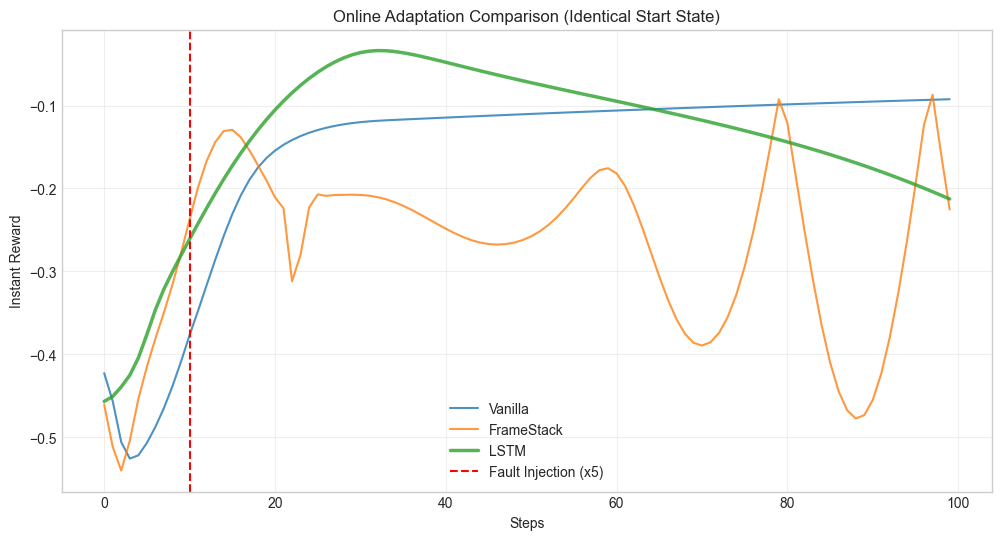

In [24]:
# Gerekli Kütüphaneler
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.utils import set_random_seed

# ==========================================
# TEST FONKSİYONU (Callable Error Fixed)
# ==========================================

def test_sudden_fault(models_map):
    print(f"\n⚡ SUDDEN FAULT TESTİ (Adil Başlangıç: Seed 42)")
    plt.figure(figsize=(12, 6))
    
    # 1. Çekirdek Ortam (Reacher-v5)
    env_core = gym.make("Reacher-v5", max_episode_steps=100)
    env_float = Float32ObservationWrapper(env_core)
    physics_ctrl = RandomDampingWrapper(env_float, 0.5, 2.0)
    
    # Modelin beklediği 12 boyutlu yapı
    env_final = PreviousActionWrapper(physics_ctrl)

    # Sabit Seed
    TEST_SEED = 44

    for name, path in models_map.items():
        # Deterministik Ortam
        set_random_seed(TEST_SEED)
        
        # Ortam Yönetimi
        if name == "FrameStack":
            env = DummyVecEnv([lambda: env_final])
            env = VecFrameStack(env, n_stack=4)
        else:
            env = DummyVecEnv([lambda: env_final])

        # Modeli Yükle
        try:
            if name == "LSTM": model = RecurrentPPO.load(path, device="cpu")
            else: model = PPO.load(path, device="cpu")
        except Exception as e:
            print(f"❌ {name} Yüklenemedi: {e}")
            continue
            
        # --- ADİL BAŞLANGIÇ AYARI (SURGICAL RESET) ---
        
        # 1. Üst seviye reset (Otomatik)
        env.reset()
        
        # 2. Alt seviye (Fizik) reset - SABİT SEED İLE
        if name == "FrameStack":
            inner_env = env.venv.envs[0] # VecFrameStack -> DummyVecEnv -> GymEnv
        else:
            inner_env = env.envs[0]      # DummyVecEnv -> GymEnv
            
        real_obs, _ = inner_env.reset(seed=TEST_SEED)

        print(f"   ► {name:<10} | Start Obs (İlk 3): {real_obs[:3]}")
        
        # 3. Üst Seviye Buffer'ı Güncelle [FIXED]
        if name == "FrameStack":
            # HATA BURADAYDI: env.stacked_obs() değil.
            # reset() metodu zaten güncel stack'i döndürür.
            obs = env.stacked_obs.reset(real_obs) 
        else:
            # Vanilla/LSTM için buffer güncellemesi
            env.buf_obs[None][0] = real_obs
            obs = env.buf_obs[None].copy()

        # Başlangıç Fiziği
        physics_ctrl.set_damping(1.0)
        
        rewards = []
        lstm_states = None
        starts = np.ones((1,), dtype=bool)
        
        # Simülasyon
        for t in range(100):
            if t == 10: 
                physics_ctrl.set_damping(3.0) # Arıza
                if name == "LSTM": print(f"   -> ⚠️ Arıza Enjekte Edildi (x5)")
                
            if name == "LSTM":
                action, lstm_states = model.predict(obs, state=lstm_states, episode_start=starts, deterministic=True)
            else:
                action, _ = model.predict(obs, deterministic=True)
            
            obs, reward, done, _ = env.step(action)
            rewards.append(reward[0])
            
            if done: starts = np.ones((1,), dtype=bool)
        
        plt.plot(rewards, label=name, linewidth=2.5 if name=="LSTM" else 1.5, alpha=0.8)

    plt.axvline(x=10, color='r', linestyle='--', label="Fault Injection (x5)")
    plt.title("Online Adaptation Comparison (Identical Start State)")
    plt.xlabel("Steps")
    plt.ylabel("Instant Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Testi Başlat
if 'models_map' in locals():
    test_sudden_fault(models_map)
else:
    try:
        # Eğer restart atıldıysa tekrar bul
        my_models = get_latest_experiment_models()
        test_sudden_fault(my_models)
    except:
        print("⚠️ Modeller bulunamadı.")